# 📌 Step1：导入依赖库、加载加州房价数据集

## 先思考问题

泰坦尼克是从 csv 网络链接读取数据，加州房价数据集在 sklearn 内置，如何加载？
加载出来的数据**不是 DataFrame**，是 Bunch 对象，不方便查看，我们优先转换成 pandas 表格方便 EDA，怎么做？

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# 加载数据
housing = fetch_california_housing()

# 将数据从 Bunch ==> DF，方便查看
x_df = pd.DataFrame(housing.data, columns=housing.feature_names)
y_df = pd.DataFrame(housing.target, columns=['MedHouseVal'])        # 添加名为 MedHouseVal 的标签
df = pd.concat([x_df, y_df], axis=1)                                # 特征+标签合并成一张完整表，方便EDA

# 设置pandas显示优化
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.max_colwidth',35)

# 设置显示中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 查看前五行
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


运行完成后观察输出表格，先看懂每一列含义：

- MedInc：街区收入中位数
- HouseAge：房屋平均房龄
- AveRooms：平均每户房间数
- AveBedrms：平均每户卧室数
- Population：街区总人口
- AveOccup：平均每户居住人数
- Latitude：纬度
- Longitude：经度
- MedHouseVal：目标：房屋中位数房价（单位：10 万美元）

# 📌Step2 引导提问

第一个问题：我们拿到数据，首先要检查两件事：

1. 数据集一共有多少条样本、多少个特征？
2. 数据里有没有缺失值？回归模型对 NaN 非常敏感。

请思考：用什么代码可以同时查看数据形状、缺失值？

In [5]:
# 查看数据集行列情况
print("数据集形状（样本数，特征数+标签数量）：", df.shape)

# 统计每一列的缺失情况
print("\n各列缺失值统计：")
print(df.isnull().sum())

# 基础统计描述，查看数值分布
print("\n数值统计描述：")
print(df.describe())

数据集形状（样本数，特征数+标签数量）： (20640, 9)

各列缺失值统计：
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

数值统计描述：
             MedInc      HouseAge      AveRooms     AveBedrms    Population      AveOccup      Latitude     Longitude   MedHouseVal
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000
mean       3.870671     28.639486      5.429000      1.096675   1425.476744      3.070655     35.631861   -119.569704      2.068558
std        1.899822     12.585558      2.474173      0.473911   1132.462122     10.386050      2.135952      2.003532      1.153956
min        0.499900      1.000000      0.846154      0.333333      3.000000      0.692308     32.540000   -124.350000      0.149990
25%        2.563400     18.000000      4.440716      1.006079    787.000000      2.429741     33.930000   -121.800000      

# 📌 Step3 引导提问

回归任务最关心：**各个特征和房价 MedHouseVal 的相关程度如何？**

我们需要计算**相关系数矩阵**，并且用热力图可视化，直观看到：
哪些特征和房价正相关、负相关、几乎无关。

思考：pandas 用什么函数计算相关系数？再搭配 matplotlib/seaborn 绘制热力图。

相关系数矩阵：
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


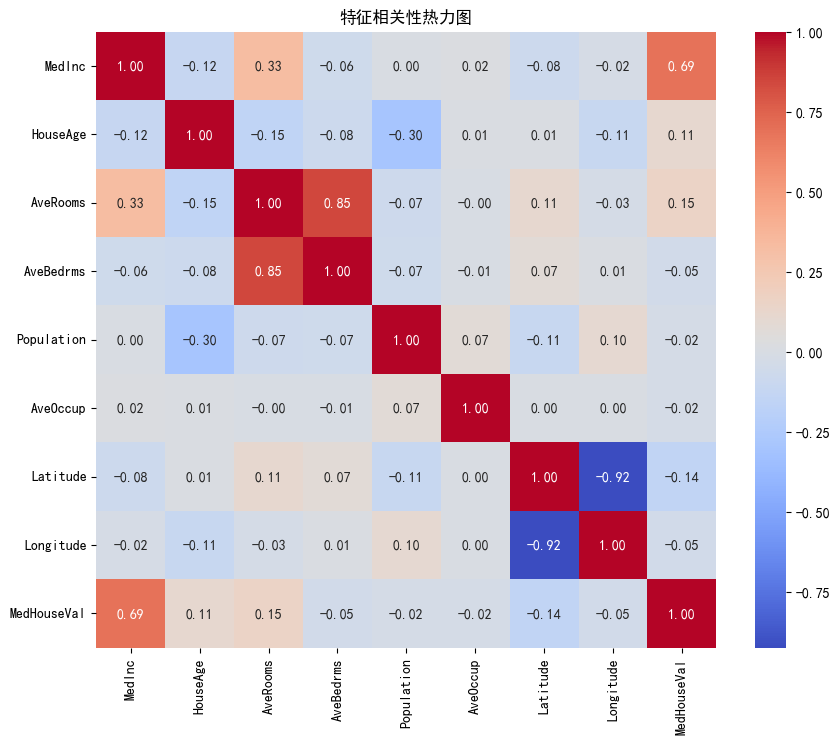

In [ ]:
# 1. 计算皮尔逊相关系数
corr_matrix = df.corr() # 计算皮尔逊相关系数，取值范围 [-1,1]
print("相关系数矩阵：")
print(corr_matrix["MedHouseVal"].sort_values(ascending=0)) # 单独取出房价与所有特征的相关系数，从高到低排序，方便快速筛选重要特征

# 2.绘制热力图
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("特征相关性热力图")
plt.show()

# 📌 Step4 引导提问

现在我们要正式划分训练集、测试集。
思考两个关键问题：

1. 回归任务拆分数据集，还需要 `stratify=y` 分层抽样吗？

> 答：stratify 是为分类任务保证每一类样本比例，回归是连续值，**不需要分层抽样**。

2. 线性回归对特征尺度敏感，建模前我们需要做什么预处理？

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 划分特征 X，标签 y
X = df.drop("MedHouseVal", axis=1) # 分离特征与预测目标
y = df["MedHouseVal"]

# 划分训练集，测试集，test_size=0.2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"训练集：X_train {X_train.shape}, y_train {y_train.shape}")
print(f"测试集：X_test {X_test.shape}, y_test {y_test.shape}")

# 标准化：线性回归必备，把特征缩放至均值 0、标准差 1
scaler = StandardScaler()

# 只用训练集拟合缩放器 scaler！
X_train_scaled = scaler.fit_transform(X_train) # 仅在训练集执行，测试集只能调用 transform

# 测试集只做transform，不能fit！
X_test_scaled = scaler.transform(X_test)

训练集：X_train (16512, 8), y_train (16512,)
测试集：X_test (4128, 8), y_test (4128,)


# 📌 Step5 搭建基线模型：线性回归 + 回归指标讲解

引导提问：泰坦尼克分类我们用：准确率、混淆矩阵、Precision/Recall。

房价是回归任务，不能用准确率！

思考：回归模型用什么指标衡量预测好坏？常用 3 个核心指标：
- MAE 平均绝对误差
- MSE 均方误差
- RMSE 均方根误差（最直观）
- $R^2$ 决定系数（0~1，越靠近 1 模型拟合效果越好）

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. 创建线性回归模型
lr = LinearRegression()

# 2. 在标准化训练集上训练
lr.fit(X_train_scaled, y_train)

# 3. 对测试集预测
y_pred = lr.predict(X_test_scaled)

# 4. 计算回归评估指标
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("========== 线性回归基线模型评估 ==========")
print(f"MAE 平均绝对误差：{mae:.4f}")
print(f"MSE 均方误差：{mse:.4f}")
print(f"RMSE 均方根误差：{rmse:.4f}")
print(f"R² 决定系数：{r2:.4f}")

# 输出特征系数，观察正负影响
coef_df = pd.DataFrame({
    "feature":X.columns,
    "coef":lr.coef_
}).sort_values("coef", ascending=False)
print("\n特征系数：")
print(coef_df)

========== 线性回归基线模型评估 ==========
MAE 平均绝对误差：0.5332
MSE 均方误差：0.5559
RMSE 均方根误差：0.7456
R² 决定系数：0.5758

特征系数：
      feature      coef
0      MedInc  0.854383
3   AveBedrms  0.339259
1    HouseAge  0.122546
4  Population -0.002308
5    AveOccup -0.040829
2    AveRooms -0.294410
7   Longitude -0.869842
6    Latitude -0.896929


# 📌 Step6 引导提问

普通最小二乘线性回归没有约束，多重共线性容易造成系数不稳定。
我们有两种带正则化的线性模型：

- **Ridge（岭回归）**：L2 正则，缩小系数，但不会把系数压缩到 0，可以保留全部特征
- **Lasso（套索回归）**：L1 正则，倾向把不重要特征系数直接压缩为 0，自带特征筛选功能

问题：正则化里面的`alpha`是什么作用？
 
> 答：alpha 越大，正则惩罚越强；alpha=0 等价于普通线性回归。

In [10]:
from sklearn.linear_model import Ridge, Lasso

# ---------- Ridge岭回归 ----------
ridge = Ridge(alpha=1.0) # 1. L2 正则线性回归，惩罚项约束权重不要过大，缓解多重共线性带来的系数震荡
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

print("========== Ridge岭回归评估 ==========")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}")
print(f"R²: {r2_score(y_test, y_pred_ridge):.4f}")

ridge_coef = pd.DataFrame({
    "feature":X.columns,
    "coef":ridge.coef_
}).sort_values("coef", ascending=False)
print("\nRidge特征系数：")
print(ridge_coef)

# ---------- Lasso套索回归 ----------
lasso = Lasso(alpha=0.01) # L1 正则线性回归，alpha 不能设置太大，否则大量特征直接被压缩为 0，欠拟合
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

print("\n========== Lasso套索回归评估 ==========")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.4f}")
print(f"R²: {r2_score(y_test, y_pred_lasso):.4f}")

lasso_coef = pd.DataFrame({
    "feature":X.columns,
    "coef":lasso.coef_
}).sort_values("coef", ascending=False)
print("\nLasso特征系数：")
print(lasso_coef)

========== Ridge岭回归评估 ==========
RMSE: 0.7456
R²: 0.5758

Ridge特征系数：
      feature      coef
0      MedInc  0.854327
3   AveBedrms  0.339008
1    HouseAge  0.122624
4  Population -0.002282
5    AveOccup -0.040833
2    AveRooms -0.294210
7   Longitude -0.869071
6    Latitude -0.896168

========== Lasso套索回归评估 ==========
RMSE: 0.7404
R²: 0.5816

Lasso特征系数：
      feature      coef
0      MedInc  0.800957
3   AveBedrms  0.206207
1    HouseAge  0.127087
4  Population -0.000000
5    AveOccup -0.030602
2    AveRooms -0.162759
7   Longitude -0.755674
6    Latitude -0.790113


# 📌 Step7 引导提问

线性模型最高 $R^2$ 只有 0.58 左右，上限较低。接下来我们使用随机森林回归 RandomForestRegressor

思考两个问题：
1. 随机森林还需要传入 X_train_scaled 标准化数据吗？
2. 回归任务的随机森林，预测输出是什么形式？

In [11]:
from sklearn.ensemble import RandomForestRegressor

# 随机森林不需要标准化！直接使用原始 X_train、X_test
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42) # 随机森林回归，和分类 RandomForestClassifier 对应
rf_reg.fit(X_train, y_train) # 直接使用原始未标准化特征，树模型不受尺度影响

y_pred_rf = rf_reg.predict(X_test) # 输出连续数值（房价），不再是 0/1 类别

# 评估指标
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("========== 随机森林回归评估 ==========")
print(f"MAE 平均绝对误差：{mae_rf:.4f}")
print(f"RMSE 均方根误差：{rmse_rf:.4f}")
print(f"R² 决定系数：{r2_rf:.4f}")

# 输出特征重要性
feature_import = pd.DataFrame({
    "feature":X.columns,
    "importance":rf_reg.feature_importances_
}).sort_values("importance", ascending=False)
print("\n特征重要性排序：")
print(feature_import)

========== 随机森林回归评估 ==========
MAE 平均绝对误差：0.3277
RMSE 均方根误差：0.5060
R² 决定系数：0.8046

特征重要性排序：
      feature  importance
0      MedInc    0.524980
5    AveOccup    0.138367
6    Latitude    0.089035
7   Longitude    0.088474
1    HouseAge    0.054602
2    AveRooms    0.044216
4  Population    0.030662
3   AveBedrms    0.029663


# 📌 Step8 引导提问

现在随机森林使用默认参数，我们可以用`GridSearchCV`进行网格搜索，寻找最优 `n_estimators` 和 `max_depth`，进一步优化泛化能力。
思考问题：

1. 随机森林回归调参，交叉验证的评估指标用什么？
2. 回归任务 GridSearchCV 的`scoring`参数应该填写什么？

In [ ]:
from sklearn.model_selection import GridSearchCV

# 划定需要尝试的两组超参数的范围
param_grid = {
    "n_estimators": [80, 120, 150], # 森林中决策树棵数
    "max_depth": [12, 16, 20, None] # 树的最大深度
}

# 基础随机森林回归器
rf = RandomForestRegressor(random_state=42)

# 网格搜索，5折交叉验证
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,         # 5折交叉验证
    scoring="r2", # 回归任务使用 R² 作为优化目标
    n_jobs=-1     # n_jobs=-1 使用电脑全部CPU，加速搜索
)

# ⚠️依旧使用原始训练集，不需要标准化
grid_search.fit(X_train, y_train)

print("✅网格搜索最优参数：")
print(grid_search.best_params_)
print(f"5折交叉验证最优 R² 得分：{grid_search.best_score_:.4f}")

# 获取最优模型
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

# 在测试集评估最优模型
print("\n======== 调参后最优随机森林测试集评估 ========")
print(f"MAE: {mean_absolute_error(y_test, y_pred_best):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}")
print(f"R² : {r2_score(y_test, y_pred_best):.4f}")

# 调参后特征重要性
feature_import_best = pd.DataFrame({
    "feature":X.columns,
    "importance":best_rf.feature_importances_
}).sort_values("importance", ascending=False)
print("\n调参后特征重要性：")
print(feature_import_best)

✅网格搜索最优参数：
{'max_depth': 20, 'n_estimators': 150}
5折交叉验证最优R²得分：0.8051

======== 调参后最优随机森林测试集评估 ========
MAE: 0.3274
RMSE: 0.5048
R² : 0.8056

调参后特征重要性：
      feature  importance
0      MedInc    0.526866
5    AveOccup    0.138129
6    Latitude    0.088430
7   Longitude    0.088305
1    HouseAge    0.054345
2    AveRooms    0.044005
4  Population    0.030544
3   AveBedrms    0.029376


# 📌 Step9 引导思考：特征工程拓展思路

现在我们只用原始 8 个特征，能不能构造新特征进一步提升模型效果？
根据业务常识，可以衍生出新特征：

1. `RoomPerBedroom = AveRooms / AveBedrms` 平均每间卧室配套房间数量
2. `PeoplePerRoom = AveOccup / AveRooms` 平均每个房间居住人数

思考：构造衍生特征后，理论上可以给模型提供更多信息。

In [ ]:
# 复制原始数据集，避免污染原 df
df_new = df.copy()

# 构造衍生特征（特征工程）
df_new["RoomPerBedroom"] = df_new["AveRooms"] / df_new["AveBedrms"]
df_new["PeoplePerRoom"] = df_new["AveOccup"] / df_new["AveRooms"]

# 重新划分 X, y
X_new = df_new.drop("MedHouseVal", axis=1)
y_new = df_new["MedHouseVal"]

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)

# 使用之前网格搜索得到的最优参数训练
best_rf = RandomForestRegressor(max_depth=20, n_estimators=150, random_state=42)
best_rf.fit(X_train_new, y_train_new)
y_pred_new = best_rf.predict(X_test_new)

print("===== 增加衍生特征后随机森林评估 =====")
print(f"MAE: {mean_absolute_error(y_test_new, y_pred_new):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_new, y_pred_new)):.4f}")
print(f"R² : {r2_score(y_test_new, y_pred_new):.4f}")

feature_import_new = pd.DataFrame({
    "feature":X_new.columns,
    "importance":best_rf.feature_importances_
}).sort_values("importance", ascending=False)
print("\n增加特征后的特征重要性：")
print(feature_import_new)

===== 增加衍生特征后随机森林评估 =====
MAE: 0.3282
RMSE: 0.5030
R² : 0.8069

增加特征后的特征重要性：
          feature  importance
0          MedInc    0.523556
5        AveOccup    0.127321
6        Latitude    0.083720
7       Longitude    0.083710
1        HouseAge    0.051844
8  RoomPerBedroom    0.028951
9   PeoplePerRoom    0.026604
4      Population    0.026565
2        AveRooms    0.025250
3       AveBedrms    0.022478


# 📌 Step10：整理全部模型指标汇总表（项目总结核心）

我们把前面所有模型结果汇总，方便写实验报告、直观对比：

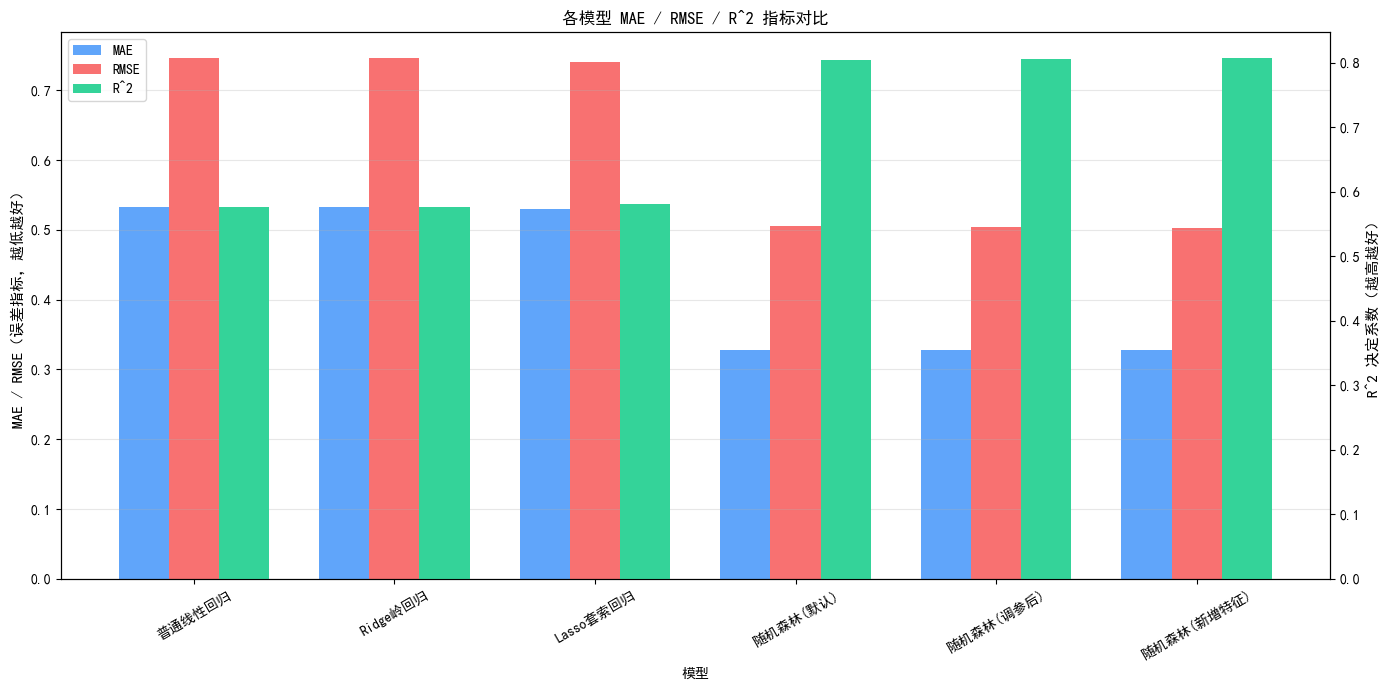

In [26]:
# 汇总所有模型结果（后续XGBoost跑完再追加一行）
result_table = pd.DataFrame({
    "模型": ["普通线性回归", "Ridge岭回归", "Lasso套索回归", "随机森林(默认)", "随机森林(调参后)", "随机森林(新增特征)"],
    "MAE":    [0.5332, 0.5332, 0.5297, 0.3277, 0.3274, 0.3282],
    "RMSE":   [0.7456, 0.7456, 0.7404, 0.5060, 0.5048, 0.5030],
    "R²":     [0.5758, 0.5758, 0.5816, 0.8046, 0.8056, 0.8069]
})

labels = result_table["模型"]
x = np.arange(len(labels))
width = 0.25  # 柱子宽度

fig, ax1 = plt.subplots(figsize=(14,7))
ax2 = ax1.twinx()  # 共享X轴，创建右侧Y轴

# 绘制三根柱子
rect1 = ax1.bar(x - width, result_table["MAE"], width, label="MAE", color="#60a5fa")
rect2 = ax1.bar(x,        result_table["RMSE"], width, label="RMSE", color="#f87171")
rect3 = ax2.bar(x + width,result_table["R²"],   width, label="R^2", color="#34d399")

ax1.set_xlabel("模型")
ax1.set_ylabel("MAE / RMSE（误差指标，越低越好）", fontsize=11)
ax2.set_ylabel("R^2 决定系数（越高越好）", fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=30)
ax1.grid(axis="y", alpha=0.3)

# 合并图例
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")

plt.title("各模型 MAE / RMSE / R^2 指标对比")
plt.tight_layout()
plt.show()

# 📌 Step11：拓展 1 —— XGBoost 回归

## 引导思考

随机森林是 Bagging；XGBoost 属于 Boosting 串行树模型，通常在表格数据上具备更强拟合能力。
XGBoost 需要标准化特征吗？

> 答：不需要！树模型不依赖特征尺度，直接使用原始特征。

In [20]:
from xgboost import XGBRegressor

# 使用新增衍生特征后的数据集 X_new, y_new
xgb_reg = XGBRegressor(
    n_estimators=150,
    max_depth=6,
    random_state=42
)
xgb_reg.fit(X_train_new, y_train_new)
y_pred_xgb = xgb_reg.predict(X_test_new)

mae_xgb = mean_absolute_error(y_test_new, y_pred_xgb)
mse_xgb = mean_squared_error(y_test_new, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test_new, y_pred_xgb)

print("========== XGBoost回归评估 ==========")
print(f"MAE:  {mae_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R² :  {r2_xgb:.4f}")

feature_import_xgb = pd.DataFrame({
    "feature":X_new.columns,
    "importance":xgb_reg.feature_importances_
}).sort_values("importance", ascending=False)
print("\nXGBoost特征重要性：")
print(feature_import_xgb)

========== XGBoost回归评估 ==========
MAE:  0.3039
RMSE: 0.4653
R² :  0.8348

XGBoost特征重要性：
          feature  importance
0          MedInc    0.453685
5        AveOccup    0.140428
7       Longitude    0.105084
6        Latitude    0.088332
1        HouseAge    0.057085
9   PeoplePerRoom    0.042789
2        AveRooms    0.037364
8  RoomPerBedroom    0.034080
3       AveBedrms    0.020747
4      Population    0.020407


# 📌 Step12：拓展 2 —— 绘制真实房价 VS 预测房价散点图

等 XGBoost 跑完，我们选用最优模型（随机森林新增特征版本 / XGBoost）画图：

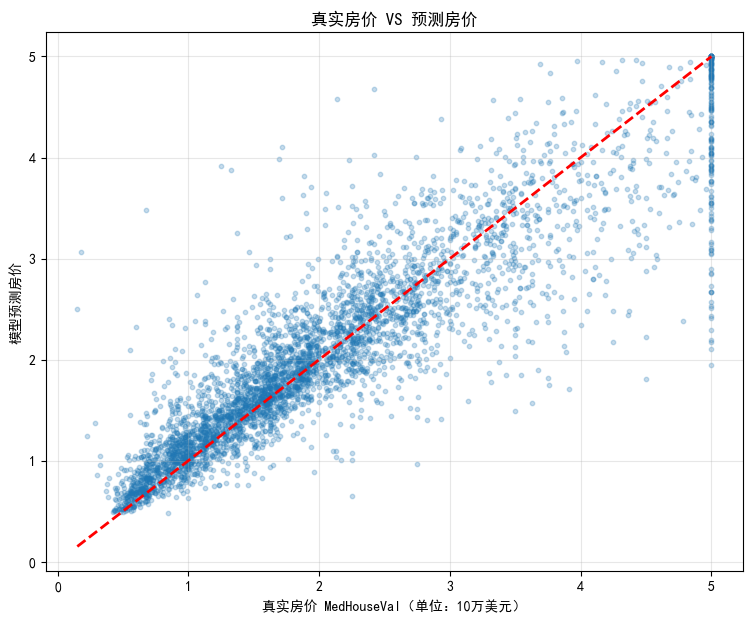

In [21]:
plt.figure(figsize=(9,7))
plt.scatter(y_test_new, y_pred_new, alpha=0.25, s=10)
# 理想预测对角线
lims = [y_test_new.min(), y_test_new.max()]
plt.plot(lims, lims, "r--", lw=2)
plt.xlabel("真实房价 MedHouseVal（单位：10万美元）")
plt.ylabel("模型预测房价")
plt.title("真实房价 VS 预测房价")
plt.grid(alpha=0.3)
plt.show()

# 📌 Step13：更新图表

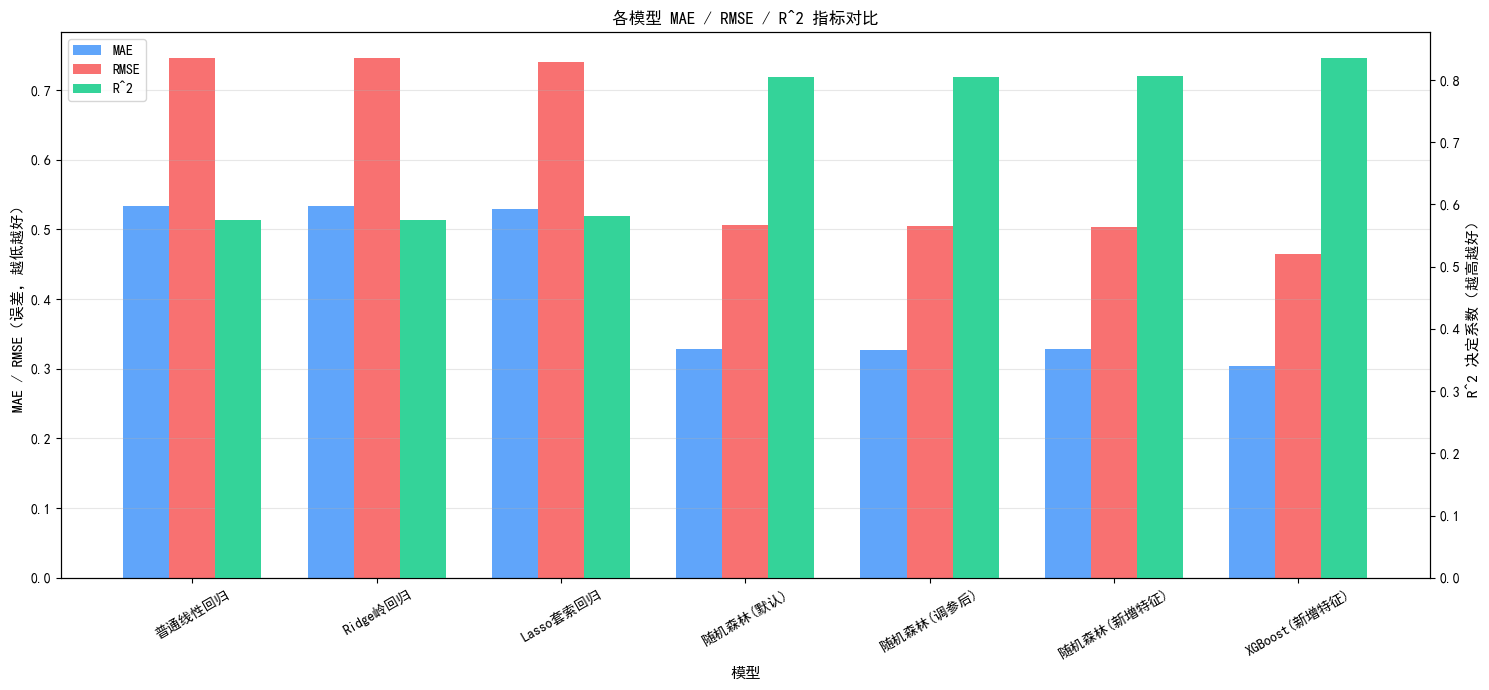

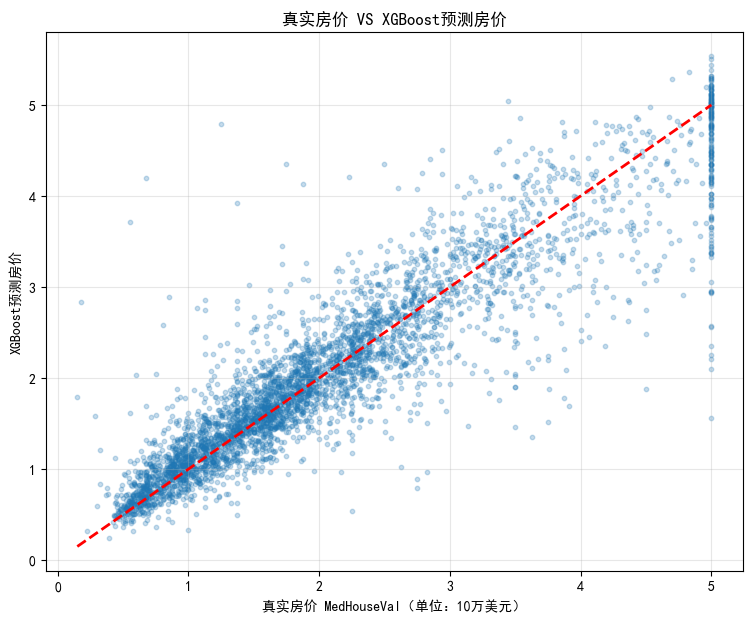

In [25]:
# ======= 完整指标汇总（新增XGBoost）=======
result_table = pd.DataFrame({
    "模型": ["普通线性回归", "Ridge岭回归", "Lasso套索回归", "随机森林(默认)", "随机森林(调参后)", "随机森林(新增特征)", "XGBoost(新增特征)"],
    "MAE":    [0.5332, 0.5332, 0.5297, 0.3277, 0.3274, 0.3282, 0.3039],
    "RMSE":   [0.7456, 0.7456, 0.7404, 0.5060, 0.5048, 0.5030, 0.4653],
    "R²":     [0.5758, 0.5758, 0.5816, 0.8046, 0.8056, 0.8069, 0.8348]
})

# 分组柱状图：每组3根柱子 MAE / RMSE / R² 双Y轴
labels = result_table["模型"]
x = np.arange(len(labels))
width = 0.25

fig, ax1 = plt.subplots(figsize=(15,7))
ax2 = ax1.twinx()

rect1 = ax1.bar(x - width, result_table["MAE"], width, label="MAE", color="#60a5fa")
rect2 = ax1.bar(x,        result_table["RMSE"], width, label="RMSE", color="#f87171")
rect3 = ax2.bar(x + width,result_table["R²"],   width, label="R^2", color="#34d399")

ax1.set_xlabel("模型", fontsize=11)
ax1.set_ylabel("MAE / RMSE（误差，越低越好）", fontsize=11)
ax2.set_ylabel("R^2 决定系数（越高越好）", fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=30)
ax1.grid(axis="y", alpha=0.3)

# 合并图例
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")

plt.title("各模型 MAE / RMSE / R^2 指标对比")
plt.tight_layout()
plt.show()

# ======= 散点图 =======
plt.figure(figsize=(9,7))
plt.scatter(y_test_new, y_pred_xgb, alpha=0.25, s=10)
# 理想预测对角线
lims = [y_test_new.min(), y_test_new.max()]
plt.plot(lims, lims, "r--", lw=2)
plt.xlabel("真实房价 MedHouseVal（单位：10万美元）")
plt.ylabel("XGBoost预测房价")
plt.title("真实房价 VS XGBoost预测房价")
plt.grid(alpha=0.3)
plt.show()